# IPCA – Subitens (IBGE/SIDRA 7060)

 Este notebook apresenta:

 **1. O que são os subitens do IPCA**  
 **2. Como o IBGE organiza a tabela 7060**  
 **3. Execução do pipeline `ipca_subitens`**  
 **4. Consulta ao banco de dados (`bcb.ipca_subitens`)**  
 **5. Gráficos e análises exploratórias por subitem**  

 Vamos começar entendendo o conceito.

# 1. O que são os subitens do IPCA?

O **IPCA (Índice Nacional de Preços ao Consumidor Amplo)** é composto por:

- grupos  
- subgrupos  
- itens  
- **subitens (nível mais desagregado)**  

Os **subitens** representam produtos e serviços específicos, como:

- arroz  
- feijão preto  
- gasolina  
- energia elétrica  

Trabalhar com subitens permite:

- análises mais finas de inflação  
- identificação de choques específicos (alimentos, combustíveis, serviços)  
- construção de núcleos e decomposições detalhadas

# 2. Tabela 7060 – IPCA por subitens

A tabela 7060 do SIDRA traz o IPCA por:

- Brasil (nível nacional)  
- grupos, subgrupos, itens e subitens  

As variáveis que usamos aqui são:

- **63** → variação mensal (%), que chamaremos de `Indice`  
- **66** → peso do subitem no índice, `Peso`  

Nosso pipeline monta a tabela `bcb.ipca_subitens` com:

- `date`  
- `indice`  
- `peso`  
- `category` (código numérico de 7 dígitos)  
- `category_name` (descrição do subitem)

# 3. Ajustar o PYTHONPATH para importar `src/`

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 4. Importações

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.ipca_subitens import run_ipca_subitens
from src.database.connection import engine

pd.set_option("display.float_format", "{:.6f}".format)

# 5. Executar pipeline IPCA subitens (IBGE – tabela 7060)

Isso irá:
- consultar a tabela 7060 do SIDRA  
- baixar as variáveis 63 (Indice) e 66 (Peso)  
- filtrar apenas subitens (nível 7)  
- criar/atualizar a tabela `bcb.ipca_subitens`  
- inserir todos os dados no PostgreSQL

In [3]:
run_ipca_subitens()

2026-04-20 19:13:21,558 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=63, periodo=all
2026-04-20 19:13:24,677 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.
2026-04-20 19:13:24,691 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=66, periodo=all
2026-04-20 19:13:26,343 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.


Tabela bcb.ipca_subitens atualizada com sucesso!


,date,indice,peso,category,category_name
0,2020-01-01,1.310000,0.475300,1101002,Arroz
1,2020-01-01,4.500000,0.011600,1101051,Feijão - mulatinho
2,2020-01-01,-2.680000,0.048600,1101052,Feijão - preto
3,2020-01-01,5.390000,0.012100,1101053,Feijão - macáçar (fradinho)
4,2020-01-01,-0.700000,0.135000,1101073,Feijão - carioca (rajado)
...,...,...,...,...,...
28270,2026-03-01,0.000000,0.383100,9101010,Tv por assinatura
28271,2026-03-01,0.000000,0.386500,9101018,Acesso à internet
28272,2026-03-01,-1.190000,0.703000,9101019,Aparelho telefônico
28273,2026-03-01,0.000000,0.078000,9101115,Serviços de streaming


# 6. Verificar tabelas existentes no schema `bcb`

In [4]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,ipca_subitens
2,selic_meta
3,selic_over


# 7. Carregar dados de IPCA subitens

In [12]:
query_ipca_subitens = """
select *
from bcb.ipca_subitens
order by "Date" desc, category;
"""

df = pd.read_sql(query_ipca_subitens, engine)
df.head()

,Date,Indice,Peso,category,categoryName
0,202603,-0.300000,0.498800,1101002,Arroz
1,202603,4.420000,0.012300,1101051,Feijão - mulatinho
2,202603,7.120000,0.035900,1101052,Feijão - preto
3,202603,2.290000,0.016000,1101053,Feijão - macáçar (fradinho)
4,202603,15.400000,0.109400,1101073,Feijão - carioca (rajado)


# 8. Primeiros registros

In [13]:
df.tail(20)

,Date,Indice,Peso,category,categoryName
28255,202001,0.000000,0.031700,8101045,Curso técnico
28256,202001,0.000000,0.030800,8102001,Jornal diário
28257,202001,0.200000,0.028000,8102004,Revista
28258,202001,1.360000,0.389800,8102007,Livro didático
28259,202001,1.290000,0.096400,8102008,Livro não didático
28260,202001,-0.600000,0.054400,8103001,Caderno
28261,202001,1.060000,0.090300,8103014,Artigos de papelaria
28262,202001,0.000000,0.078000,8104001,Curso preparatório
28263,202001,0.000000,0.309200,8104003,Curso de idioma
28264,202001,1.630000,0.001600,8104004,Curso de informática


# 9. Estatísticas básicas

In [14]:
df.describe()

,Indice,Peso
count,28275.000000,28275.000000
mean,0.554964,0.265252
std,3.490774,0.606299
min,-36.450000,0.000300
25%,-0.310000,0.016200
50%,0.310000,0.071100
75%,1.210000,0.238000
max,55.410000,6.839300


# 10. Subitens com maior peso médio

Aqui vemos quais subitens têm maior relevância estrutural no IPCA.

In [17]:
top_peso = (
    df.groupby(["category", "categoryName"])["Peso"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_peso

,category,categoryName,Peso
0,5104001,Gasolina,5.295207
1,2202003,Energia elétrica residencial,4.203493
2,6203001,Plano de saúde,3.920041
3,2101001,Aluguel residencial,3.681344
4,1201001,Refeição,3.598515
5,5102001,Automóvel novo,3.069677
6,7101010,Empregado doméstico,2.834456
7,5102004,Emplacamento e licença,2.526589
8,2101002,Condomínio,2.229884
9,2101004,Taxa de água e esgoto,1.807539


# 11. Evolução da variação mensal de um subitem específico

Vamos escolher um subitem de interesse (por exemplo, gasolina) e analisar sua trajetória.

In [19]:
# Exemplo: filtrar por parte do nome (ajuste conforme necessário)
filtro = "gasolina"

sub = df[df["categoryName"].str.contains(filtro, case=False, na=False)]

sub.head()

,Date,Indice,Peso,category,categoryName
286,202603,4.590000,5.090700,5104001,Gasolina
663,202602,-0.610000,5.155600,5104001,Gasolina
1040,202601,2.060000,5.067900,5104001,Gasolina
1417,202512,0.180000,5.075400,5104001,Gasolina
1794,202511,-0.420000,5.105600,5104001,Gasolina


2026-04-20 18:07:14,687 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-20 18:07:14,692 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


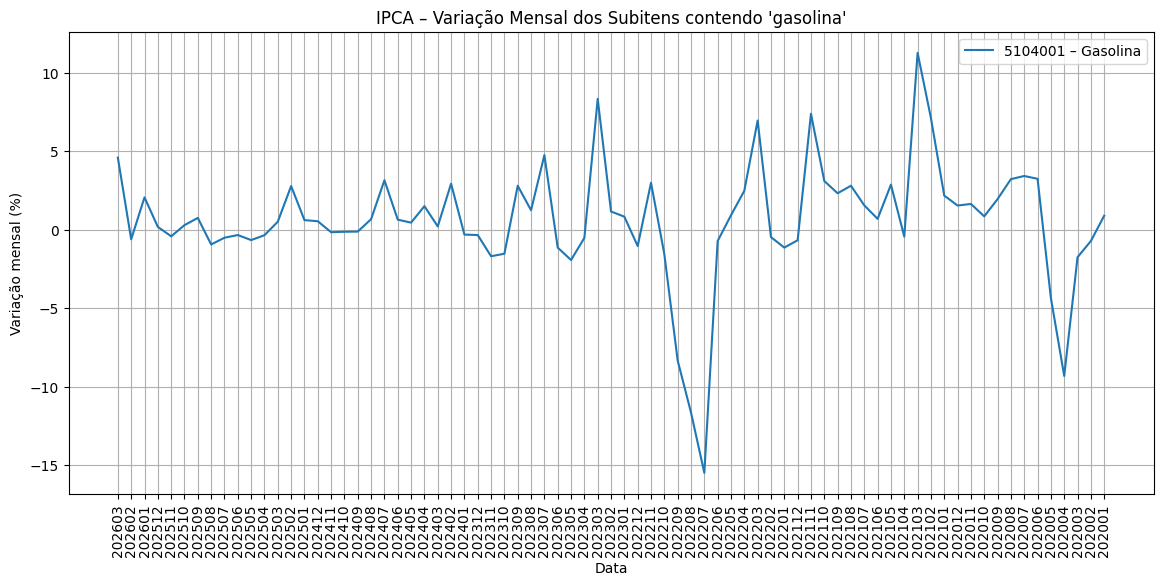

In [21]:
plt.figure(figsize=(14, 6))
for cat, g in sub.groupby("category"):
    plt.plot(g["Date"], g["Indice"], label=f"{cat} – {g['categoryName'].iloc[0]}")

plt.title(f"IPCA – Variação Mensal dos Subitens contendo '{filtro}'")
plt.xlabel("Data")
plt.xticks(rotation=90)
plt.ylabel("Variação mensal (%)")
plt.grid(True)
plt.legend()
plt.show()

# 12. Heatmap de variação mensal – últimos 12 meses

Útil para visualizar rapidamente quais subitens aceleraram ou desaceleraram recentemente.

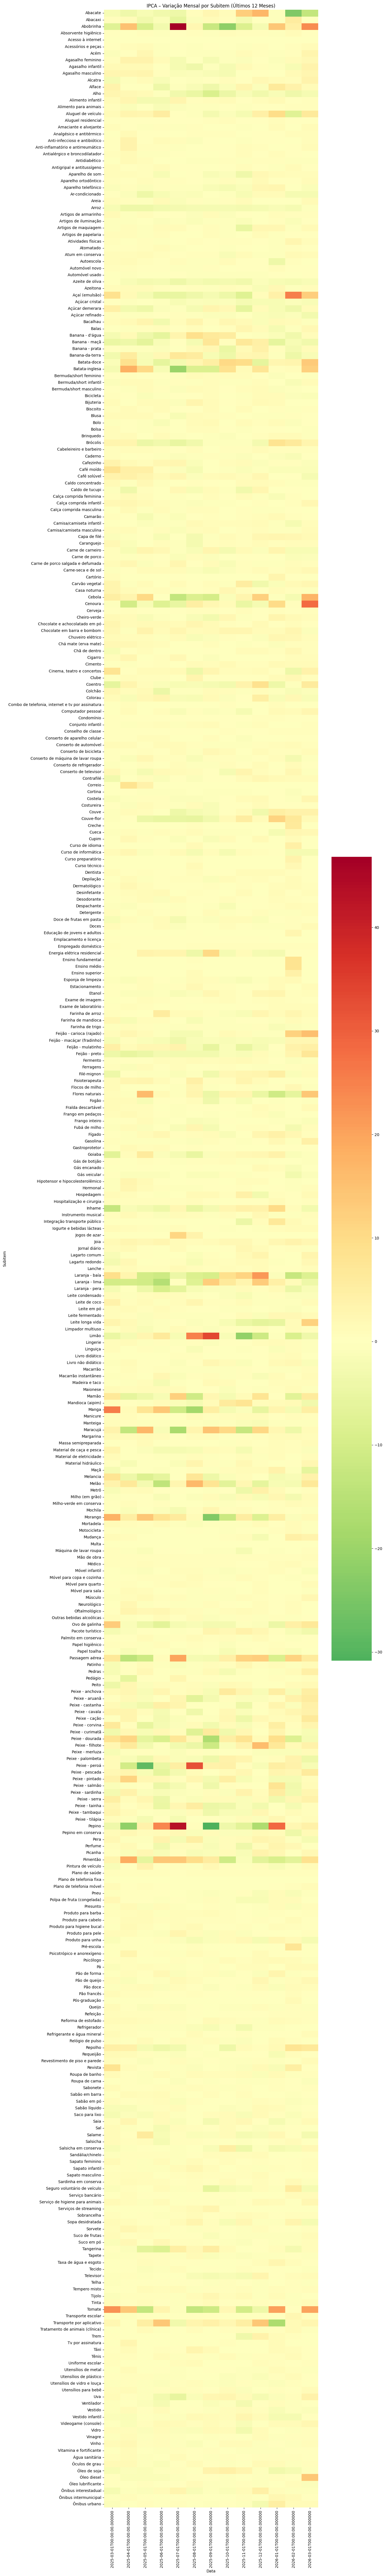

In [27]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y%m")
df_recent = df[df["Date"] >= df["Date"].max() - pd.offsets.DateOffset(months=12)]

pivot_hm = df_recent.pivot_table(
    index="categoryName",
    columns="Date",
    values="Indice"
)

plt.figure(figsize=(14, max(6, len(pivot_hm) * 0.25)))
sns.heatmap(
    pivot_hm,
    cmap="RdYlGn_r",
    center=0,
    annot=False
)
plt.title("IPCA – Variação Mensal por Subitem (Últimos 12 Meses)")
plt.xlabel("Data")
plt.ylabel("Subitem")
plt.tight_layout()
plt.show()

# 13. Distribuição da variação mensal por subitem

Aqui avaliamos a dispersão da inflação entre subitens em um mês recente.

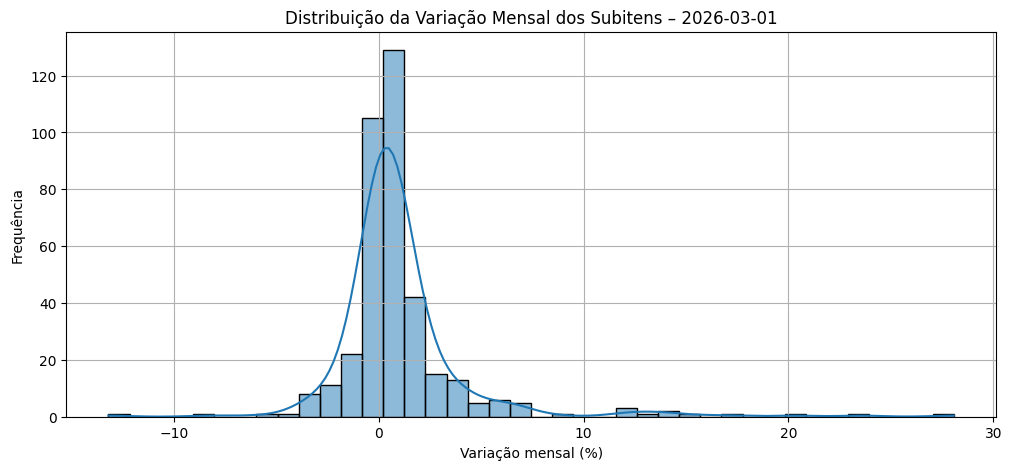

In [28]:
ultimo_mes = df["Date"].max()
df_ult = df[df["Date"] == ultimo_mes]

plt.figure(figsize=(12, 5))
sns.histplot(df_ult["Indice"], bins=40, kde=True)
plt.title(f"Distribuição da Variação Mensal dos Subitens – {ultimo_mes.date()}")
plt.xlabel("Variação mensal (%)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

# 14. Conclusões

- A tabela `bcb.ipca_subitens` traz o IPCA no nível mais desagregado (subitens).  
- As colunas `indice` e `peso` permitem análises de contribuição e relevância de cada subitem.  
- A estrutura `category` (código) + `category_name` (descrição) facilita junções e painéis.  
- Este pipeline é a base para:
  - decomposição da inflação por produto/serviço  
  - construção de núcleos e medidas alternativas  
  - análises setoriais e de choques específicos.  

Próximos passos:
- Integrar esta tabela com o IPCA geral (`bcb.ipca`)  
- Construir decomposições por grupo, subgrupo e subitem  
- Criar dashboards e relatórios automatizados de inflação por subitem